In [1]:
# Setup and installations
!wget -O blaze_face_short_range.tflite \
https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite

from google.colab import drive
drive.mount('/content/drive')

!pip uninstall -y torch torchvision torchaudio
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install mediapipe scikit-learn --quiet

--2026-02-07 20:40:53--  https://storage.googleapis.com/mediapipe-models/face_detector/blaze_face_short_range/float16/1/blaze_face_short_range.tflite
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.130.207, 74.125.68.207, 172.253.118.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.130.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 229746 (224K) [application/octet-stream]
Saving to: ‘blaze_face_short_range.tflite’

blaze_face_short_ra 100%[===================>] 224.36K   393KB/s    in 0.6s    

2026-02-07 20:40:54 (393 KB/s) - ‘blaze_face_short_range.tflite’ saved [229746/229746]

Mounted at /content/drive
Found existing installation: torch 2.9.0+cu126
Uninstalling torch-2.9.0+cu126:
  Successfully uninstalled torch-2.9.0+cu126
Found existing installation: torchvision 0.24.0+cu126
Uninstalling torchvision-0.24.0+cu126:
  Successfully uninstalled torchvision-0.24.0+cu126
Found existing installation: torchaud

In [2]:
import os
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
from tqdm import tqdm
import mediapipe as mp
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.utils.class_weight import compute_class_weight
import matplotlib.pyplot as plt
import json
import pickle
from collections import Counter

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## Step 1: Preprocessing (Unchanged but with better error handling)

In [3]:
# Initialize MediaPipe face detector
BaseOptions = mp.tasks.BaseOptions
FaceDetectorOptions = mp.tasks.vision.FaceDetectorOptions
VisionRunningMode = mp.tasks.vision.RunningMode

detector = mp.tasks.vision.FaceDetector.create_from_options(
    FaceDetectorOptions(
        base_options=BaseOptions(model_asset_path='/content/blaze_face_short_range.tflite'),
        running_mode=VisionRunningMode.IMAGE,
        min_detection_confidence=0.5
    )
)

DATASET_ROOT = "/content/drive/MyDrive/state-farm-distracted-driver-detection/imgs/train"
SAVE_ROOT = "/content/preprocessed_dataset"

os.makedirs(SAVE_ROOT, exist_ok=True)

classes = sorted([c for c in os.listdir(DATASET_ROOT) if os.path.isdir(os.path.join(DATASET_ROOT, c))])

# Track preprocessing statistics
stats = {'total': 0, 'face_detected': 0, 'no_face': 0, 'errors': 0}

for c in classes:
    class_dir = os.path.join(DATASET_ROOT, c)
    save_class_dir = os.path.join(SAVE_ROOT, c)
    os.makedirs(save_class_dir, exist_ok=True)

    for fname in tqdm(os.listdir(class_dir), desc=f"Processing class {c}"):
        if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        try:
            path = os.path.join(class_dir, fname)
            frame = cv2.imread(path)
            if frame is None:
                stats['errors'] += 1
                continue

            stats['total'] += 1
            H, W, _ = frame.shape

            # Face detection with better fallback
            rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
            result = detector.detect(mp_image)

            if result and result.detections and len(result.detections) > 0:
                stats['face_detected'] += 1
                face = result.detections[0].bounding_box
                # Add padding around face
                x1 = max(0, int(face.origin_x - 0.25 * face.width))
                y1 = max(0, int(face.origin_y - 0.25 * face.height))
                x2 = min(W, int(face.origin_x + face.width + 0.25 * face.width))
                y2 = min(H, int(face.origin_y + face.height + 0.25 * face.height))
                face_roi = frame[y1:y2, x1:x2]
            else:
                stats['no_face'] += 1
                # Use center crop as fallback
                face_roi = frame[H//4:3*H//4, W//4:3*W//4]

            # Hand region (bottom-right quadrant)
            hand_roi = frame[H//2:H, W//2:W]
            full_roi = frame.copy()

            def preprocess(img):
                """Preprocess image to tensor"""
                img = cv2.resize(img, (224, 224))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img.astype(np.float32) / 255.0
                img = torch.from_numpy(img).permute(2, 0, 1).contiguous()
                mean = torch.tensor([0.485, 0.456, 0.406], dtype=img.dtype).view(3,1,1)
                std  = torch.tensor([0.229, 0.224, 0.225], dtype=img.dtype).view(3,1,1)
                return (img - mean) / std

            # Save preprocessed tensors
            save_path = os.path.join(save_class_dir, fname.split('.')[0] + ".pt")
            torch.save({
                "full": preprocess(full_roi),
                "face": preprocess(face_roi),
                "hand": preprocess(hand_roi)
            }, save_path)

        except Exception as e:
            print(f"Error processing {fname}: {e}")
            stats['errors'] += 1
            continue

print("\nPreprocessing Statistics:")
print(f"Total images: {stats['total']}")
print(f"Face detected: {stats['face_detected']} ({100*stats['face_detected']/max(stats['total'],1):.1f}%)")
print(f"No face (fallback used): {stats['no_face']} ({100*stats['no_face']/max(stats['total'],1):.1f}%)")
print(f"Errors: {stats['errors']}")

Processing class c9: 100%|██████████| 2129/2129 [01:30<00:00, 23.53it/s]


Preprocessing Statistics:
Total images: 22424
Face detected: 17797 (79.4%)
No face (fallback used): 4627 (20.6%)
Errors: 0


## Step 2: Improved Dataset with Augmentation

In [4]:
class DriverDataset(Dataset):
    """Driver action dataset with optional data augmentation"""
    def __init__(self, root_dir, transform=None):
        self.samples = []
        self.transform = transform

        classes = sorted([c for c in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, c))])
        self.class_map = {c: idx for idx, c in enumerate(classes)}
        self.class_names = {idx: c for c, idx in self.class_map.items()}

        for c in classes:
            class_dir = os.path.join(root_dir, c)
            for fname in os.listdir(class_dir):
                if fname.endswith(".pt"):
                    self.samples.append((os.path.join(class_dir, fname), self.class_map[c]))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        data = torch.load(path, weights_only=False)  # Explicitly set for compatibility

        full = data["full"]
        face = data["face"]
        hand = data["hand"]

        # Apply augmentation if provided (only during training)
        if self.transform:
            # Denormalize
            mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
            std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

            full = full * std + mean
            face = face * std + mean
            hand = hand * std + mean

            # Apply transforms
            full = self.transform(full)
            face = self.transform(face)
            hand = self.transform(hand)

        return full, face, hand, label

    def get_labels(self):
        """Return all labels for stratified splitting"""
        return [label for _, label in self.samples]

## Step 3: Improved Model Architecture

In [5]:
class ImprovedDriverActionClassifier(nn.Module):
    """Improved model with regularization and better architecture"""
    def __init__(self, backbone, num_classes=10, dropout_p=0.5):
        super().__init__()
        self.backbone = backbone

        # Multi-layer classifier with BatchNorm and Dropout
        self.classifier = nn.Sequential(
            nn.Linear(3 * 576, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_p * 0.6),  # Lower dropout in second layer

            nn.Linear(256, num_classes)
        )

    def forward(self, full, face, hand):
        """Forward pass with three separate inputs"""
        # Extract features from each view
        full_feat = self.backbone(full).flatten(1)  # (B, 576)
        face_feat = self.backbone(face).flatten(1)  # (B, 576)
        hand_feat = self.backbone(hand).flatten(1)  # (B, 576)

        # Concatenate all features
        combined = torch.cat([full_feat, face_feat, hand_feat], dim=1)  # (B, 1728)

        # Classify
        return self.classifier(combined)


class DriverActionClassifierForONNX(nn.Module):
    """ONNX-compatible version with single concatenated input"""
    def __init__(self, backbone, classifier):
        super().__init__()
        self.backbone = backbone
        self.classifier = classifier

    def forward(self, x):
        """x shape: (B, 3, 3, 224, 224) - [batch, views, channels, H, W]"""
        B = x.shape[0]
        # Reshape to (B*3, 3, 224, 224)
        x = x.view(B * 3, 3, 224, 224)

        # Extract features
        feats = self.backbone(x)  # (B*3, 576)
        feats = feats.flatten(1)

        # Reshape back to (B, 1728)
        feats = feats.view(B, -1)

        # Classify
        return self.classifier(feats)

## Step 4: Proper Train/Val/Test Split with Stratification

In [6]:
DATASET_ROOT = "/content/preprocessed_dataset"

# Load full dataset (no augmentation yet)
full_dataset = DriverDataset(DATASET_ROOT)

# Get all labels for stratification
all_labels = full_dataset.get_labels()
print(f"Total samples: {len(all_labels)}")
print("\nClass distribution:")
label_counts = Counter(all_labels)
for label, count in sorted(label_counts.items()):
    print(f"  Class {label}: {count} samples ({100*count/len(all_labels):.1f}%)")

# Create stratified train/temp split (80/20)
train_indices, temp_indices = train_test_split(
    range(len(full_dataset)),
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

# Split temp into val/test (50/50 of the 20% = 10% each)
temp_labels = [all_labels[i] for i in temp_indices]
val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.5,
    stratify=temp_labels,
    random_state=42
)

print(f"\nSplit sizes:")
print(f"  Train: {len(train_indices)} ({100*len(train_indices)/len(all_labels):.1f}%)")
print(f"  Val:   {len(val_indices)} ({100*len(val_indices)/len(all_labels):.1f}%)")
print(f"  Test:  {len(test_indices)} ({100*len(test_indices)/len(all_labels):.1f}%)")

# Define data augmentation (ONLY for training)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.RandomRotation(degrees=5),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# No augmentation for val/test
eval_transform = None

# Create datasets with appropriate transforms
train_dataset_aug = DriverDataset(DATASET_ROOT, transform=train_transform)
train_dataset_aug.samples = [full_dataset.samples[i] for i in train_indices]

val_dataset = DriverDataset(DATASET_ROOT, transform=eval_transform)
val_dataset.samples = [full_dataset.samples[i] for i in val_indices]

test_dataset = DriverDataset(DATASET_ROOT, transform=eval_transform)
test_dataset.samples = [full_dataset.samples[i] for i in test_indices]

# Create data loaders
train_loader = DataLoader(
    train_dataset_aug,
    batch_size=32,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Verify a batch
full, face, hand, labels = next(iter(train_loader))
print(f"\nBatch shapes:")
print(f"  Full: {full.shape}")
print(f"  Face: {face.shape}")
print(f"  Hand: {hand.shape}")
print(f"  Labels: {labels.shape}")

Total samples: 22424

Class distribution:
  Class 0: 2489 samples (11.1%)
  Class 1: 2267 samples (10.1%)
  Class 2: 2317 samples (10.3%)
  Class 3: 2346 samples (10.5%)
  Class 4: 2326 samples (10.4%)
  Class 5: 2312 samples (10.3%)
  Class 6: 2325 samples (10.4%)
  Class 7: 2002 samples (8.9%)
  Class 8: 1911 samples (8.5%)
  Class 9: 2129 samples (9.5%)

Split sizes:
  Train: 17939 (80.0%)
  Val:   2242 (10.0%)
  Test:  2243 (10.0%)

Batch shapes:
  Full: torch.Size([32, 3, 224, 224])
  Face: torch.Size([32, 3, 224, 224])
  Hand: torch.Size([32, 3, 224, 224])
  Labels: torch.Size([32])


## Step 5: Compute Class Weights for Balanced Loss

In [7]:
# Compute class weights to handle imbalance
train_labels = [all_labels[i] for i in train_indices]
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:")
for i, w in enumerate(class_weights):
    print(f"  Class {i}: {w:.3f}")

Class weights:
  Class 0: 0.901
  Class 1: 0.989
  Class 2: 0.968
  Class 3: 0.956
  Class 4: 0.964
  Class 5: 0.970
  Class 6: 0.964
  Class 7: 1.120
  Class 8: 1.173
  Class 9: 1.053


## Step 6: Initialize Model and Training Components

In [8]:
# Create backbone
mobilenet = models.mobilenet_v3_small(weights=models.MobileNet_V3_Small_Weights.DEFAULT)
mobilenet.classifier = nn.Identity()  # Remove original classifier

# Create model
model = ImprovedDriverActionClassifier(
    backbone=mobilenet,
    num_classes=10,
    dropout_p=0.5
).to(device)

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer with weight decay (L2 regularization)
optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4  # L2 regularization
)

# Learning rate scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3,
    verbose=True
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth
100%|██████████| 9.83M/9.83M [00:00<00:00, 217MB/s]

Model parameters: 1,947,690
Trainable parameters: 1,947,690



/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## Step 7: Training Loop with Early Stopping and Metrics

In [9]:
def train_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    pbar = tqdm(loader, desc="Training")
    for full, face, hand, labels in pbar:
        full = full.to(device)
        face = face.to(device)
        hand = hand.to(device)
        labels = labels.to(device)

        # Forward pass
        logits = model(full, face, hand)
        loss = criterion(logits, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        total_loss += loss.item() * labels.size(0)
        pred = logits.argmax(dim=1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100*correct/total:.2f}%'
        })

    return total_loss / total, correct / total


def evaluate(model, loader, criterion, device):
    """Evaluate model"""
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for full, face, hand, labels in tqdm(loader, desc="Evaluating"):
            full = full.to(device)
            face = face.to(device)
            hand = hand.to(device)
            labels = labels.to(device)

            logits = model(full, face, hand)
            loss = criterion(logits, labels)

            total_loss += loss.item() * labels.size(0)
            pred = logits.argmax(dim=1)

            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(all_labels)
    accuracy = 100 * np.mean(np.array(all_preds) == np.array(all_labels))
    f1 = f1_score(all_labels, all_preds, average='weighted')

    return avg_loss, accuracy, f1, all_preds, all_labels


# Training configuration
NUM_EPOCHS = 50
PATIENCE = 7
BEST_MODEL_PATH = "/content/drive/MyDrive/best_driver_model.pth"

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'val_f1': [],
    'lr': []
}

best_val_loss = float('inf')
patience_counter = 0

print("Starting training...\n")

for epoch in range(NUM_EPOCHS):
    print(f"\n{'='*60}")
    print(f"Epoch {epoch + 1}/{NUM_EPOCHS}")
    print(f"{'='*60}")

    # Train
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)

    # Validate
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)

    # Update learning rate
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']

    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)
    history['lr'].append(current_lr)

    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {100*train_acc:.2f}%")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}% | Val F1: {val_f1:.4f}")
    print(f"  Learning Rate: {current_lr:.2e}")

    # Early stopping check
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        # Save best model
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1': val_f1,
        }, BEST_MODEL_PATH)

        print(f"  ✓ New best model saved! (Val Loss: {val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"  No improvement for {patience_counter} epoch(s)")

        if patience_counter >= PATIENCE:
            print(f"\n{'='*60}")
            print(f"Early stopping triggered after {epoch + 1} epochs")
            print(f"Best validation loss: {best_val_loss:.4f}")
            print(f"{'='*60}")
            break

print("\nTraining complete!")

Starting training...


Epoch 1/50


Evaluating: 100%|██████████| 71/71 [00:17<00:00,  4.11it/s]



Results:
  Train Loss: 0.9859 | Train Acc: 73.79%
  Val Loss:   0.4161 | Val Acc:   90.19% | Val F1: 0.8992
  Learning Rate: 1.00e-04
  ✓ New best model saved! (Val Loss: 0.4161)

Epoch 2/50


Evaluating: 100%|██████████| 71/71 [00:16<00:00,  4.42it/s]



Results:
  Train Loss: 0.1988 | Train Acc: 96.46%
  Val Loss:   0.1774 | Val Acc:   95.67% | Val F1: 0.9560
  Learning Rate: 1.00e-04
  ✓ New best model saved! (Val Loss: 0.1774)

Epoch 3/50


...


Results:
  Train Loss: 0.0013 | Train Acc: 99.98%
  Val Loss:   0.0240 | Val Acc:   99.46% | Val F1: 0.9946
  Learning Rate: 2.50e-05
  No improvement for 5 epoch(s)

Epoch 32/50


Evaluating: 100%|██████████| 71/71 [00:02<00:00, 25.50it/s]



Results:
  Train Loss: 0.0013 | Train Acc: 99.98%
  Val Loss:   0.0172 | Val Acc:   99.64% | Val F1: 0.9964
  Learning Rate: 2.50e-05
  No improvement for 6 epoch(s)

Epoch 33/50


Evaluating: 100%|██████████| 71/71 [00:02<00:00, 25.59it/s]


Results:
  Train Loss: 0.0012 | Train Acc: 99.98%
  Val Loss:   0.0173 | Val Acc:   99.64% | Val F1: 0.9964
  Learning Rate: 2.50e-05
  No improvement for 7 epoch(s)

Early stopping triggered after 33 epochs
Best validation loss: 0.0154

Training complete!


## Step 8: Plot Training History

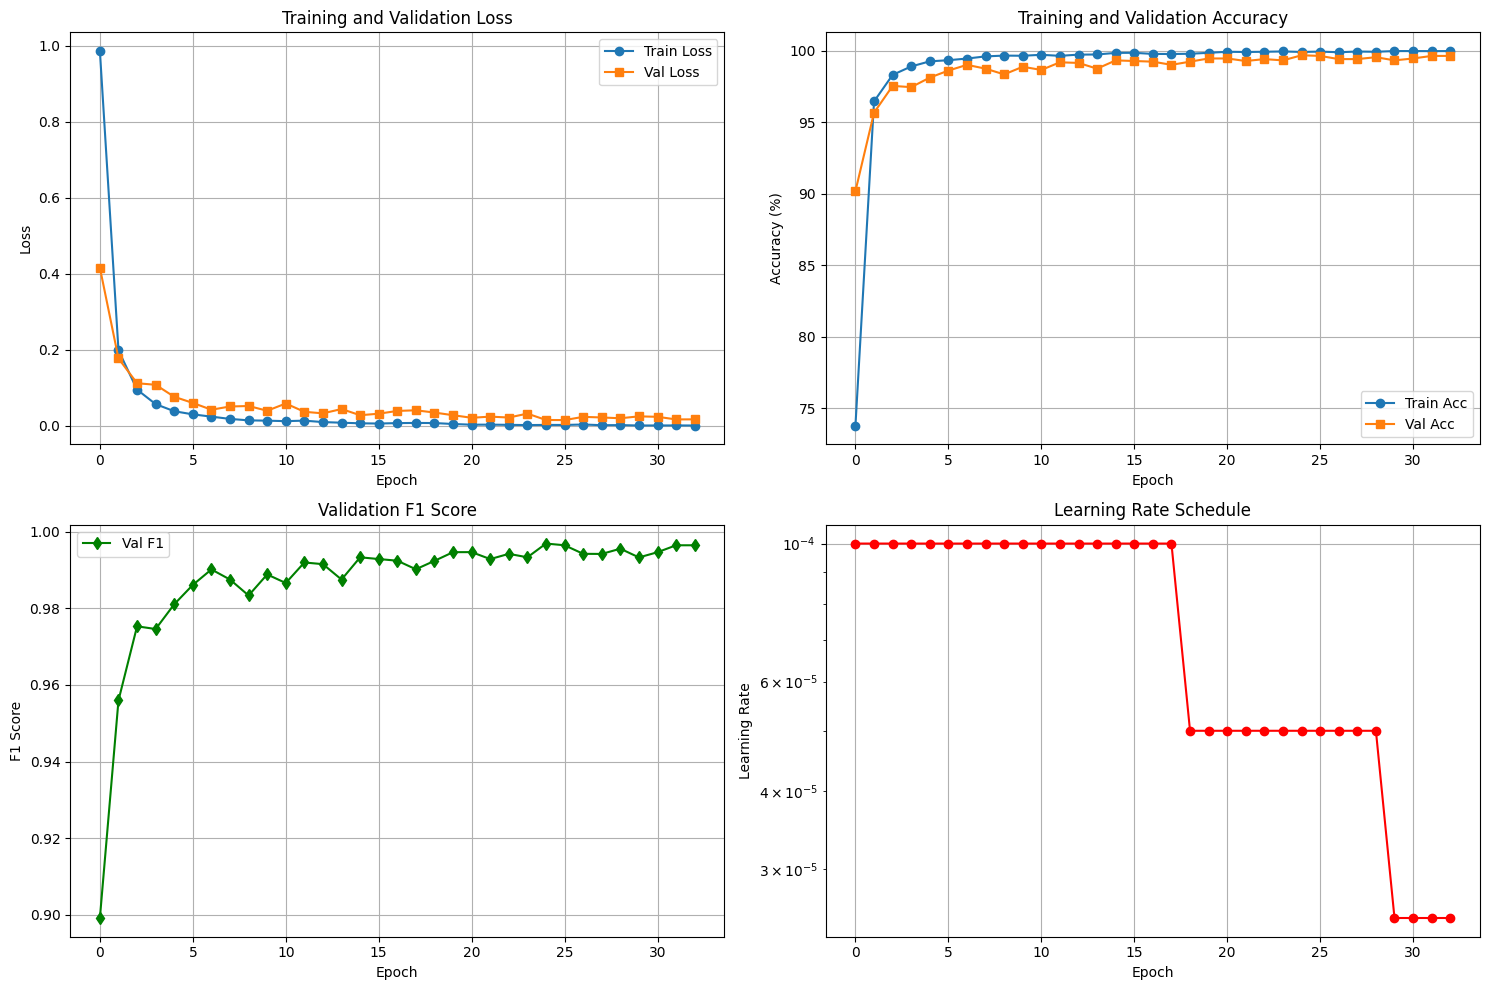

Training history plot saved!


In [10]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0, 0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot([100*x for x in history['train_acc']], label='Train Acc', marker='o')
axes[0, 1].plot(history['val_acc'], label='Val Acc', marker='s')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# F1 Score
axes[1, 0].plot(history['val_f1'], label='Val F1', marker='d', color='green')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1 Score')
axes[1, 0].set_title('Validation F1 Score')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Learning Rate
axes[1, 1].plot(history['lr'], marker='o', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Learning Rate')
axes[1, 1].set_title('Learning Rate Schedule')
axes[1, 1].set_yscale('log')
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/training_history.png', dpi=150)
plt.show()

print("Training history plot saved!")

## Step 9: Evaluate on Test Set

/tmp/ipython-input-2688475027.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(BEST_MODEL_PATH)


Loaded best model from epoch 26
  Val Loss: 0.0154
  Val Acc:  99.64%
  Val F1:   0.9964

Evaluating on test set...


Evaluating: 100%|██████████| 71/71 [00:21<00:00,  3.36it/s]



TEST SET RESULTS
Test Loss: 0.0232
Test Acc:  99.33%
Test F1:   0.9933

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      1.00      1.00       249
     Class 1       0.99      1.00      0.99       226
     Class 2       0.99      1.00      1.00       232
     Class 3       0.99      1.00      0.99       235
     Class 4       1.00      1.00      1.00       233
     Class 5       1.00      1.00      1.00       231
     Class 6       0.98      1.00      0.99       233
     Class 7       1.00      1.00      1.00       200
     Class 8       1.00      0.95      0.98       191
     Class 9       1.00      0.99      0.99       213

    accuracy                           0.99      2243
   macro avg       0.99      0.99      0.99      2243
weighted avg       0.99      0.99      0.99      2243


Confusion Matrix:
[[249   0   0   0   0   0   0   0   0   0]
 [  1 225   0   0   0   0   0   0   0   0]
 [  0   0 232   0   0   0   0   0   0   

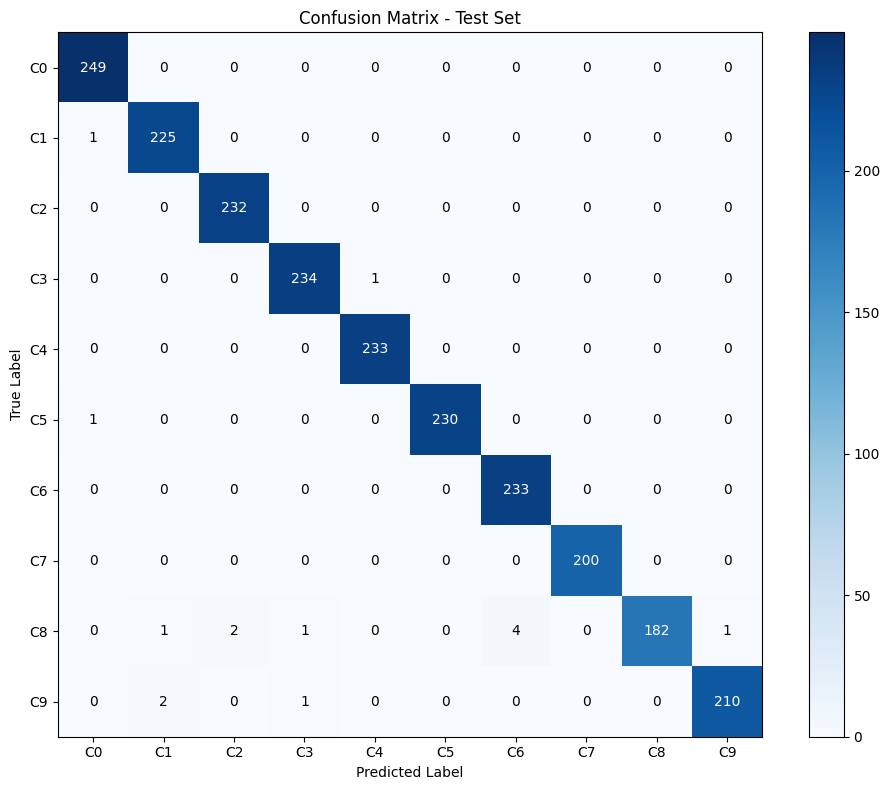

In [11]:
# Load best model
checkpoint = torch.load(BEST_MODEL_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch'] + 1}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val Acc:  {checkpoint['val_acc']:.2f}%")
print(f"  Val F1:   {checkpoint['val_f1']:.4f}")

# Evaluate on test set
print("\nEvaluating on test set...")
test_loss, test_acc, test_f1, test_preds, test_labels = evaluate(
    model, test_loader, criterion, device
)

print(f"\n{'='*60}")
print("TEST SET RESULTS")
print(f"{'='*60}")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Acc:  {test_acc:.2f}%")
print(f"Test F1:   {test_f1:.4f}")

# Detailed classification report
print("\nClassification Report:")
print(classification_report(
    test_labels,
    test_preds,
    target_names=[f"Class {i}" for i in range(10)]
))

# Confusion matrix
print("\nConfusion Matrix:")
cm = confusion_matrix(test_labels, test_preds)
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix - Test Set')
plt.colorbar()
tick_marks = np.arange(10)
plt.xticks(tick_marks, [f"C{i}" for i in range(10)])
plt.yticks(tick_marks, [f"C{i}" for i in range(10)])
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Add text annotations
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/confusion_matrix.png', dpi=150)
plt.show()

## Step 10: Export to ONNX (Fixed Version)

In [12]:
!pip install onnx onnxruntime onnxscript --quiet

import onnx
import onnxruntime as ort

# Create ONNX-compatible model using the SAME trained backbone and classifier
onnx_model = DriverActionClassifierForONNX(
    backbone=model.backbone,
    classifier=model.classifier
).to(device)

onnx_model.eval()

# Create dummy input (batch_size=1, views=3, channels=3, H=224, W=224)
dummy_input = torch.randn(1, 3, 3, 224, 224, device=device)

# Verify the model works
with torch.no_grad():
    test_output = onnx_model(dummy_input)
    print(f"Test output shape: {test_output.shape}")
    print(f"Test output (logits): {test_output[0].cpu().numpy()}")

# Export to ONNX
onnx_file = "/content/driver_action.onnx"

torch.onnx.export(
    onnx_model,
    dummy_input,
    onnx_file,
    export_params=True,
    opset_version=17,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["logits"],
    dynamic_axes={
        "input": {0: "batch"},
        "logits": {0: "batch"}
    }
)

print(f"\nONNX export complete: {onnx_file}")

# Verify ONNX model
onnx_model_check = onnx.load(onnx_file)
onnx.checker.check_model(onnx_model_check)
print("✓ ONNX model check passed")

# Test ONNX Runtime inference
sess = ort.InferenceSession(onnx_file, providers=["CPUExecutionProvider"])

# Create test input
x_test = np.random.randn(2, 3, 3, 224, 224).astype(np.float32)
onnx_output = sess.run(None, {"input": x_test})

print(f"\n✓ ONNX Runtime output shape: {onnx_output[0].shape}")  # Should be (2, 10)
print("✓ ONNX Runtime inference test passed")

# Copy to Google Drive
!cp {onnx_file} /content/drive/MyDrive/driver_action.onnx
print("\n✓ ONNX model saved to Google Drive")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 100.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 90.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 53.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 17.7 MB/s eta 0:00:00
Test output shape: torch.Size([1, 10])
Test output (logits): [-1.9887167  -1.559117   -2.180122   -0.8666531  -5.338752   -0.65240735
 -3.2805805   6.0381536  -1.7177489  -1.3843569 ]

ONNX export complete: /content/driver_action.onnx
✓ ONNX model check passed

✓ ONNX Runtime output shape: (2, 10)
✓ ONNX Runtime inference test passed

✓ ONNX model saved to Google Drive


## Step 11: Save Class Mapping and Metadata

In [13]:
CLASS_NAMES = {
    0: "safe driving",
    1: "texting - right",
    2: "talking on the phone - right",
    3: "texting - left",
    4: "talking on the phone - left",
    5: "operating the radio",
    6: "drinking",
    7: "reaching behind",
    8: "hair and makeup",
    9: "talking to passenger"
}

# Save as JSON
with open("/content/drive/MyDrive/driver_class_map.json", "w") as f:
    json.dump(CLASS_NAMES, f, indent=2)

# Save as pickle (for compatibility)
with open("/content/drive/MyDrive/class_mapping.pkl", "wb") as f:
    pickle.dump(CLASS_NAMES, f)

# Save training metadata
metadata = {
    "model_type": "ImprovedDriverActionClassifier",
    "backbone": "MobileNetV3-Small",
    "num_classes": 10,
    "input_size": [224, 224],
    "num_views": 3,
    "best_epoch": checkpoint['epoch'] + 1,
    "best_val_loss": float(checkpoint['val_loss']),
    "best_val_acc": float(checkpoint['val_acc']),
    "best_val_f1": float(checkpoint['val_f1']),
    "test_loss": float(test_loss),
    "test_acc": float(test_acc),
    "test_f1": float(test_f1),
    "class_names": CLASS_NAMES,
    "training_config": {
        "batch_size": 32,
        "learning_rate": 1e-4,
        "weight_decay": 1e-4,
        "dropout": 0.5,
        "optimizer": "AdamW",
        "scheduler": "ReduceLROnPlateau",
        "augmentation": "RandomHorizontalFlip, ColorJitter, RandomRotation, RandomAffine"
    }
}

with open("/content/drive/MyDrive/model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("✓ Class mapping and metadata saved")
print("\nAll files saved to Google Drive:")
print("  - best_driver_model.pth")
print("  - driver_action.onnx")
print("  - driver_class_map.json")
print("  - class_mapping.pkl")
print("  - model_metadata.json")
print("  - training_history.png")
print("  - confusion_matrix.png")

✓ Class mapping and metadata saved

All files saved to Google Drive:
  - best_driver_model.pth
  - driver_action.onnx
  - driver_class_map.json
  - class_mapping.pkl
  - model_metadata.json
  - training_history.png
  - confusion_matrix.png


## Step 12: Test Inference Function

In [14]:
def predict_driver_action(model, full, face, hand, class_names):
    """Predict driver action from three views"""
    model.eval()
    device = next(model.parameters()).device

    with torch.no_grad():
        # Add batch dimension if needed
        if full.dim() == 3:
            full = full.unsqueeze(0)
            face = face.unsqueeze(0)
            hand = hand.unsqueeze(0)

        # Move to device
        full = full.to(device)
        face = face.to(device)
        hand = hand.to(device)

        # Forward pass
        logits = model(full, face, hand)
        probs = torch.softmax(logits, dim=1)

        # Get prediction
        pred_idx = probs.argmax(dim=1).item()
        pred_prob = probs[0, pred_idx].item()

        return {
            'class_id': pred_idx,
            'class_name': class_names[pred_idx],
            'confidence': pred_prob,
            'probabilities': {class_names[i]: probs[0, i].item() for i in range(10)}
        }


# Test on a random validation sample
idx = np.random.randint(len(val_dataset))
full, face, hand, true_label = val_dataset[idx]

result = predict_driver_action(model, full, face, hand, CLASS_NAMES)

print("\nTest Prediction:")
print(f"  True Label: {CLASS_NAMES[true_label]}")
print(f"  Predicted:  {result['class_name']}")
print(f"  Confidence: {100*result['confidence']:.2f}%")
print("\nTop 3 Predictions:")
sorted_probs = sorted(result['probabilities'].items(), key=lambda x: x[1], reverse=True)
for name, prob in sorted_probs[:3]:
    print(f"  {name}: {100*prob:.2f}%")


Test Prediction:
  True Label: reaching behind
  Predicted:  reaching behind
  Confidence: 99.77%

Top 3 Predictions:
  reaching behind: 99.77%
  hair and makeup: 0.06%
  talking to passenger: 0.05%
